### Simple (Binary) Thresholding

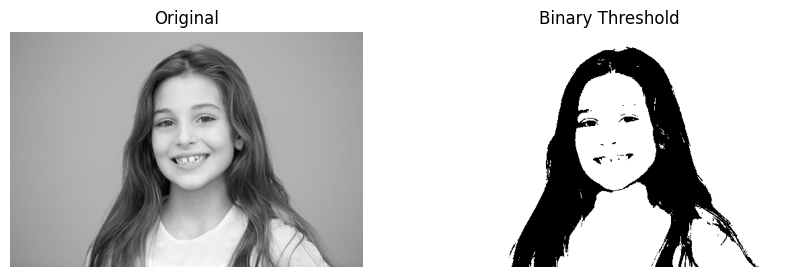

In [4]:
import cv2
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Error: Could not load image.")
    exit()

# Binary Threshold
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Threshold")
plt.axis("off")

plt.show()

### Adaptive Thresholding

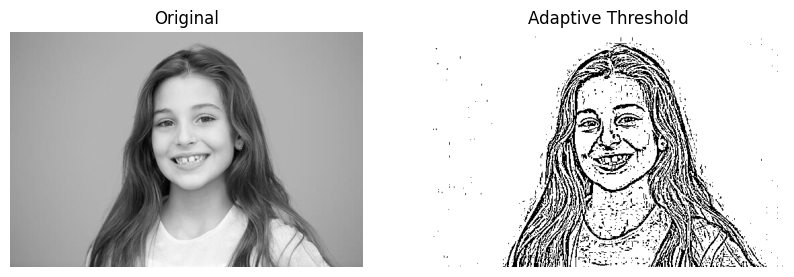

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)

adaptive = cv2.adaptiveThreshold(
    image,
    255,                                   # Maximum value to use with the THRESH_BINARY and THRESH_BINARY_INV thresholding types.
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,        # The adaptive method to use. In this case, it uses a Gaussian-weighted sum of the neighborhood values minus the constant C.
    cv2.THRESH_BINARY,                     # The type of thresholding to apply. In this case, it uses binary thresholding.
    11,                                    # The size of the neighborhood area used to calculate the threshold value for each pixel. It must be an odd number (e.g., 3, 5, 7, ...).
    2                                      # The constant subtracted from the mean or weighted mean calculated for the neighborhood. This value helps to fine-tune the thresholding result.
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(adaptive, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

### Multilevel Thresholding

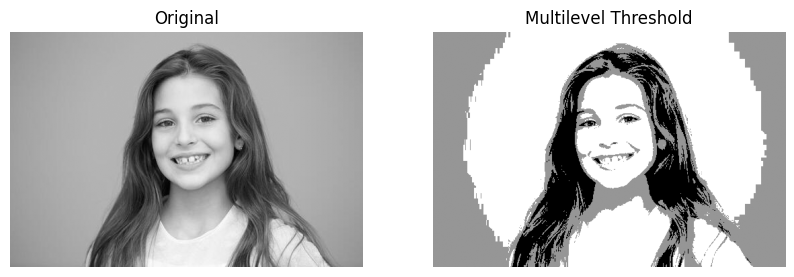

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)

result = np.zeros_like(image)

# Three intensity levels
result[image < 85] = 0
result[(image >= 85) & (image < 170)] = 150
result[image >= 170] = 255

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap="gray")
plt.title("Multilevel Threshold")
plt.axis("off")

plt.show()

### Color Thresholding (HSV)

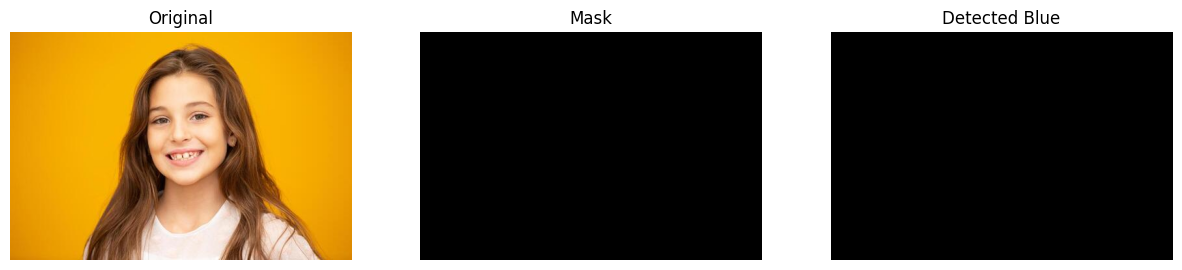

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg")

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Detect Blue Color
lower_blue = np.array([100,150,50])
upper_blue = np.array([140,255,255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)

result = cv2.bitwise_and(image, image, mask=mask)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Blue")
plt.axis("off")

plt.show()

### Local Thresholding (Sliding Window Example)

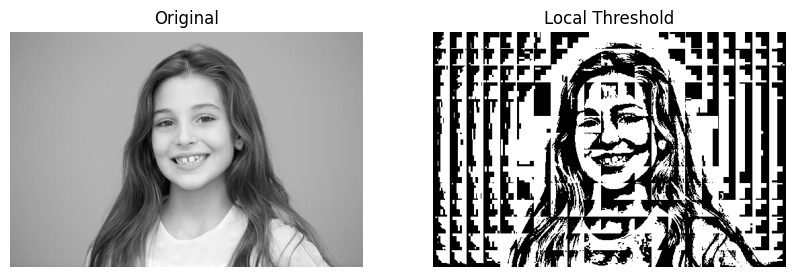

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)

window = 25
result = np.zeros_like(image)

for y in range(0, image.shape[0], window):
    for x in range(0, image.shape[1], window):

        block = image[y:y+window, x:x+window]

        threshold = np.mean(block)

        result[y:y+window, x:x+window] = np.where(
            block > threshold,
            255,
            0
        )

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Local Threshold")
plt.axis("off")

plt.show()

### Global Thresholding

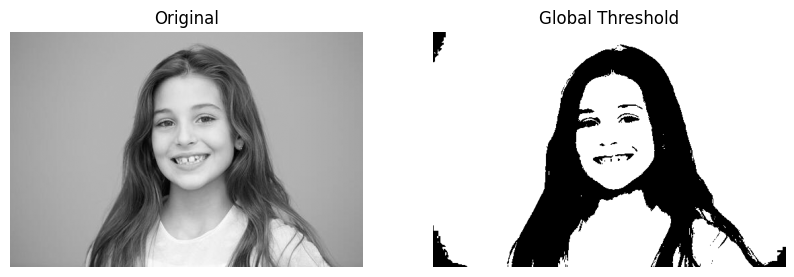

In [16]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)

threshold_value = 150

_, global_thresh = cv2.threshold(
    image,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Threshold")
plt.axis("off")

plt.show()

### Iterative Thresholding

Final Threshold = 125.7680079230156


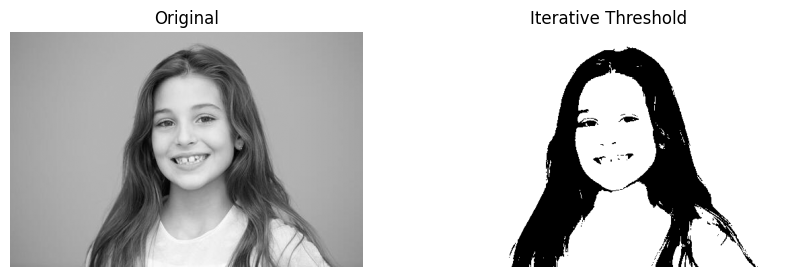

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image1.jpg", cv2.IMREAD_GRAYSCALE)

# Initial threshold
T = 127

while True:

    group1 = image[image > T]
    group2 = image[image <= T]

    if len(group1) == 0 or len(group2) == 0:
        break

    m1 = np.mean(group1)
    m2 = np.mean(group2)

    new_T = (m1 + m2) / 2

    if abs(T - new_T) < 1:
        break

    T = new_T

_, result = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)

print("Final Threshold =", T)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Iterative Threshold")
plt.axis("off")

plt.show()